# MERRA2-to-PRISM Downscaling: Model Fine-tuning

This notebook demonstrates how to fine-tune the Prithvi WxC downscaling model using MERRA2 predictors and PRISM targets.

We show how to:
1. Set up the environment and paths
2. Load the MERRA_PRISM configuration
3. Build dataloaders from the MERRA2/PRISM datasets
4. Initialize the U-Net model with pretrained weights
5. Run fine-tuning and visualize training losses

---

## Setup

Python >= 3.10 is required

Make sure that your current working directory is `granite-wxc/`

In [1]:
import os
import sys
from pathlib import Path

# Set REPO_ROOT to the granite-wxc repository root
REPO_ROOT = Path(".").resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

MERRA_PRISM_DIR = REPO_ROOT / "examples" / "MERRA_PRISM"
if str(MERRA_PRISM_DIR) not in sys.path:
    sys.path.insert(0, str(MERRA_PRISM_DIR))

os.chdir(REPO_ROOT)
print(f"Repository root: {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")

Repository root: /data/granite-wxc
Working directory: /data/granite-wxc


In [2]:
!pip install -q git+https://github.com/NASA-IMPACT/Prithvi-WxC.git

In [3]:
!pip install -q h5netcdf matplotlib xarray scipy torch tqdm pyyaml

In [4]:
# Install granitewxc in editable mode from the repo source
!pip install -q -e {REPO_ROOT}

In [5]:
import logging
import warnings

logging.disable(logging.CRITICAL)
warnings.simplefilter(action="ignore", category=FutureWarning)

---

## GPU Configuration

Configure GPU selection and hardware settings.

In [6]:
import subprocess

# ===================== HARDWARE CONFIGURATION (EDIT ME) =====================
force_visible_devices = None  # e.g. "0" or "0,1" to pin specific GPUs
max_gpus = 1                  # number of GPUs to expose
seed = 42
resume_from_checkpoint = True

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


def _query_gpu_stats():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=index,memory.total,memory.used,utilization.gpu",
             "--format=csv,noheader,nounits"],
            text=True,
        )
    except Exception:
        return []
    stats = []
    for raw in out.strip().splitlines():
        if not raw.strip():
            continue
        idx_str, total_str, used_str, util_str = [p.strip() for p in raw.split(",")]
        total_mb = int(total_str)
        used_mb = int(used_str)
        stats.append({"index": int(idx_str), "total_mb": total_mb,
                      "used_mb": used_mb, "free_mb": max(total_mb - used_mb, 0)})
    return stats


gpu_stats = _query_gpu_stats()
if force_visible_devices is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(force_visible_devices)
elif gpu_stats:
    ranked = sorted(gpu_stats, key=lambda g: -g["free_mb"])
    selected = [g["index"] for g in ranked[:max_gpus]]
    os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in selected)

import torch

use_gpu = torch.cuda.is_available()
device = torch.device("cuda" if use_gpu else "cpu")
print(f"Device: {device}")
if use_gpu:
    print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'all')}")
    print(f"GPU count: {torch.cuda.device_count()}")

Device: cuda
CUDA_VISIBLE_DEVICES: 2
GPU count: 1


In [7]:
import numpy as np
import torch

torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True

---

## Configuration

Load the MERRA_PRISM YAML configuration file. This file controls:
- Data paths (predictors, targets, scalars)
- Date ranges for training/inference
- Model architecture settings
- Training hyperparameters

In [8]:
from granitewxc.utils.config import get_config

# ===================== USER PARAMETERS (EDIT ME) =====================
CONFIG_PATH = MERRA_PRISM_DIR / "MERRA_PRISM.yaml"
NUM_GPUS = 2         # Number of GPUs for training
SAVE_EVERY = 5       # Save checkpoint every N epochs
# ====================================================================

config_path = str(CONFIG_PATH.resolve())
config = get_config(config_path)

print(f"Config: {config_path}")
print(f"Job ID: {config.job_id}")
print(f"Epochs: {config.num_epochs}")
print(f"Learning rate: {config.learning_rate}")
print(f"Batch size: {config.batch_size}")

Config: /data/granite-wxc/examples/MERRA_PRISM/MERRA_PRISM.yaml
Job ID: MERRA_PRISM
Epochs: 10
Learning rate: 5e-05
Batch size: 1


---

## Dataloader

Build dataloaders from the MERRA2 predictor and PRISM target files.
The `MerraPrismDataset` handles:
- Discovering daily MERRA2 files and PRISM target files
- Aligning dates between predictors and targets
- Applying normalization using pre-computed scalars

In [9]:
from merra_prism_training import get_dataloaders

train_loader, val_loader = get_dataloaders(config_path, config)
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

[dataset] loaded static elevation (3105, 7025) from prism_elevation.nc
[dataset] loaded static elevation (3105, 7025) from prism_elevation.nc
Training batches: 7292
Validation batches: 7292


### Sample Shapes

Verify the tensor shapes from the dataloader.

In [10]:
example_batch = next(iter(train_loader))
print(f"Input (x) shape:  {example_batch['x'].shape}")
print(f"Target (y) shape: {example_batch['y'].shape}")

Input (x) shape:  torch.Size([1, 13, 96, 256])
Target (y) shape: torch.Size([1, 3, 3105, 7025])


---

## Model Initialization

We use the **U-Net** architecture which:
1. Extracts shallow features via patch embedding
2. Uses the Prithvi backbone for deep feature extraction
3. Decodes with skip connections for high-resolution output

Pretrained weights are loaded from the path specified in the YAML config (`path_model_weights`).

In [11]:
import importlib, merra_prism_training
importlib.reload(merra_prism_training)
from merra_prism_training import create_finetune_model

model = create_finetune_model(config)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

[predictands] tmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmin: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[model] predictand configuration:
  - ppt: scaling=divide_only
  - tmax: scaling=zscore
  - tmin: scaling=zscore
Creating the model.
[predictands] tmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmin: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmin: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> model has 246,413,834 params.
[model] loaded 12 tensors, skipped 196
Total parameters: 37

---

## Fine-tuning

Launch the training loop. The `run_training` function handles:
- Single-GPU or multi-GPU (DDP/FSDP) training
- Optimizer (AdamW) and scheduler (CosineAnnealingLR)
- Gradient scaling for mixed precision
- Periodic checkpoint saving

In [12]:
from merra_prism_training import run_training

if resume_from_checkpoint:
    config.resume_training = True
    config.resume_from_last_checkpoint = True
    config.resume_checkpoint_path = None
    print("Resume enabled: training will continue from the latest checkpoint if one exists.")

train_losses, val_losses = run_training(
    config=config,
    config_path=config_path,
    num_gpus=NUM_GPUS,
    save_every=SAVE_EVERY,
)

if train_losses is not None:
    print(f"\nTraining complete!")
    print(f"  Epochs in history: {len(train_losses)}")
    print(f"  Final train loss: {train_losses[-1]:.6f}")
    print(f"  Final val loss:   {val_losses[-1]:.6f}")


[training] single-GPU mode
[dataset] loaded static elevation (3105, 7025) from prism_elevation.nc
[dataset] loaded static elevation (3105, 7025) from prism_elevation.nc
[predictands] tmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmin: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[model] predictand configuration:
  - ppt: scaling=divide_only
  - tmax: scaling=zscore
  - tmin: scaling=zscore
Creating the model.
[predictands] tmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmin: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tmin: allow_negative_value=False but no

Training Epoch 1/10:   0%|          | 0/7292 [00:00<?, ?batch/s]/home/azureuser/miniforge3/envs/Prithvi/lib/python3.14/contextlib.py:109: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
Validation Epoch: 100%|██████████| 100/100 [01:09<00:00,  1.44batch/s, loss=5.17]


--> saved ./examples/MERRA_PRISM/experiments/checkpoints/best.ckpt
--> saved ./examples/MERRA_PRISM/experiments/checkpoints/last.ckpt
Learning rate: 4.88008846492312e-05
Rank 0 starting epoch 2...


Validation Epoch: 100%|██████████| 100/100 [01:17<00:00,  1.29batch/s, loss=5.01]


--> saved ./examples/MERRA_PRISM/experiments/checkpoints/best.ckpt
--> saved ./examples/MERRA_PRISM/experiments/checkpoints/last.ckpt
Learning rate: 4.5320916362186164e-05
Rank 0 starting epoch 3...


...

--> saved ./examples/MERRA_PRISM/experiments/checkpoints/best.ckpt
--> saved ./examples/MERRA_PRISM/experiments/checkpoints/last.ckpt
Learning rate: 5.679083637813785e-06
Rank 0 starting epoch 9...


Validation Epoch: 100%|██████████| 100/100 [01:08<00:00,  1.45batch/s, loss=3.43]


--> saved ./examples/MERRA_PRISM/experiments/checkpoints/best.ckpt
--> saved ./examples/MERRA_PRISM/experiments/checkpoints/last.ckpt
Learning rate: 2.199115350768761e-06
Rank 0 starting epoch 10...


Validation Epoch: 100%|██████████| 100/100 [01:21<00:00,  1.23batch/s, loss=3.48]


--> saved ./examples/MERRA_PRISM/experiments/checkpoints/epoch_010.ckpt
--> saved ./examples/MERRA_PRISM/experiments/checkpoints/best.ckpt
--> saved ./examples/MERRA_PRISM/experiments/checkpoints/last.ckpt

Training complete!
  Epochs: 10
  Final train loss: 5.071607
  Final val loss:   4.430248


---

## Training Loss Curves

Visualize training and validation loss over epochs.

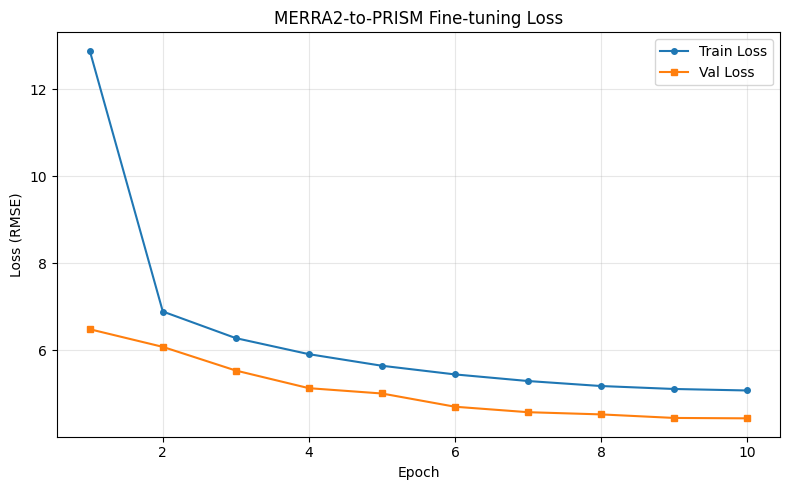

In [13]:
import matplotlib.pyplot as plt

if train_losses is not None and val_losses is not None:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, label="Train Loss", marker="o", markersize=4)
    ax.plot(epochs, val_losses, label="Val Loss", marker="s", markersize=4)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (RMSE)")
    ax.set_title("MERRA2-to-PRISM Fine-tuning Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No loss data available to plot.")

---

## Summary

After fine-tuning, checkpoints are saved under the experiment directory specified in the YAML:

```
examples/MERRA_PRISM/experiments/checkpoints/
├── best.ckpt
└── last.ckpt
```

Use the `merra_prism_inference.ipynb` notebook (or the CLI script `merra_prism_inference.py`) to run inference with the trained checkpoint.